In [59]:
pip install google-cloud-bigquery pandas-gbq pyarrow pandas numpy matplotlib seaborn plotly ipykernel

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# Cell 1: Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from datetime import datetime
from google.cloud import bigquery
import pandas_gbq

# Display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

print('All imports successful.')
print(f'Pandas version:  {pd.__version__}')
print(f'NumPy version:   {np.__version__}')
print(f'Run timestamp:   {datetime.now().strftime("%Y-%m-%d %H:%M")}')

All imports successful.
Pandas version:  2.3.3
NumPy version:   2.4.4
Run timestamp:   2026-05-27 10:37


In [61]:
# Cell 2: Project configuration

# BigQuery project ID
GCP_PROJECT_ID = 'tariff-prediction'

# Analysis window — aligned to GDELT 2.0 reliability
START_DATE = '2015-04-01'
END_DATE   = '2024-12-31'

# NVS-relevant entities in GDELT format
# GDELT uses ISO3-style 3-letter codes
# Single source of truth — all queries below pull from this list
NVS_COUNTRIES_GDELT = [
    'USA',  # United States — anchor
    'CHN',  # China — anchor
    'EUR',  # European Union — bloc proxy (use as primary EU signal in GDELT)
    'DEU',  # Germany — EU member, EU proxy when EUR unavailable
    'FRA',  # France — EU member
    'DNK',  # Denmark — NVS HQ, sparse coverage, kept for forensic value
    'IND',  # India — production + emerging market
    'BRA',  # Brazil — South America anchor
    'CAN',  # Canada — NAFTA
    'MEX',  # Mexico — NAFTA supply-chain corridor
    'JPN',  # Japan — APAC proxy
    'KOR',  # South Korea — APAC proxy
]

# Human-readable labels for plots and reports
COUNTRY_LABELS = {
    'USA': 'United States',
    'CHN': 'China',
    'EUR': 'European Union',
    'DEU': 'Germany',
    'FRA': 'France',
    'DNK': 'Denmark',
    'IND': 'India',
    'BRA': 'Brazil',
    'CAN': 'Canada',
    'MEX': 'Mexico',
    'JPN': 'Japan',
    'KOR': 'South Korea',
}

# CAMEO codes most relevant to trade/tariff prediction
TRADE_CAMEO_CODES = [
    '163',   # Impose administrative sanctions
    '1621',  # Impose import/export restrictions
    '1231',  # Threaten economic sanctions
    '0251',  # Appeal for economic cooperation
    '1031',  # Demand economic cooperation
    '155',   # Halt negotiations
]

# Key tariff events for annotation on plots
TARIFF_EVENTS = {
    '2018-03-22': 'US Section 301 announced',
    '2018-07-06': 'US $34B tariffs effective',
    '2019-05-10': 'US raises tariffs to 25%',
    '2020-01-15': 'Phase 1 Deal signed',
}

print('Configuration loaded.')
print(f'Analysis window: {START_DATE} to {END_DATE}')
print(f'Entities in scope ({len(NVS_COUNTRIES_GDELT)}): {NVS_COUNTRIES_GDELT}')
print(f'CAMEO codes tracked: {TRADE_CAMEO_CODES}')

Configuration loaded.
Analysis window: 2015-04-01 to 2024-12-31
Entities in scope (12): ['USA', 'CHN', 'EUR', 'DEU', 'FRA', 'DNK', 'IND', 'BRA', 'CAN', 'MEX', 'JPN', 'KOR']
CAMEO codes tracked: ['163', '1621', '1231', '0251', '1031', '155']


In [62]:
# Cell 3: BigQuery connection test
# This runs a minimal query to confirm authentication works
# It does NOT query GDELT yet — just checks the connection

client = bigquery.Client(project=GCP_PROJECT_ID)

test_query = """
SELECT 
    'Connection successful' AS status,
    CURRENT_TIMESTAMP() AS timestamp,
    'tariff-prediction' AS project
"""

test_result = client.query(test_query).to_dataframe()
print(test_result.to_string(index=False))

               status                        timestamp           project
Connection successful 2026-05-27 08:38:05.212651+00:00 tariff-prediction


In [63]:
# Cell 5: Diagnose actual GDELT country codes
# We remove all country filters and just count what codes exist
# This tells us exactly how GDELT labels our countries

diagnose_query = """
SELECT
    Actor1CountryCode,
    COUNT(*) AS event_count
FROM `gdelt-bq.gdeltv2.events`
WHERE
    SQLDATE BETWEEN 20180101 AND 20180331
    AND Actor1CountryCode IS NOT NULL
    AND Actor1CountryCode != ''
GROUP BY Actor1CountryCode
ORDER BY event_count DESC
LIMIT 50
"""

print('Checking actual GDELT country codes...')

codes_df = pandas_gbq.read_gbq(
    diagnose_query,
    project_id=GCP_PROJECT_ID,
    progress_bar_type=None
)

print(f'Top 50 Actor1CountryCode values in GDELT (Q1 2018):')
display(codes_df)

Checking actual GDELT country codes...
Top 50 Actor1CountryCode values in GDELT (Q1 2018):


,Actor1CountryCode,event_count
0,USA,3091684
1,RUS,554530
2,GBR,544340
3,TUR,326419
4,ISR,313699
5,CHN,310131
6,FRA,276871
7,CAN,267369
8,SYR,258148
9,EUR,243891


In [64]:
# Cell 7: Raw GDELT sample with corrected country codes
# Country filter sourced from NVS_COUNTRIES_GDELT in Cell 2

country_filter_sql = ','.join(f"'{c}'" for c in NVS_COUNTRIES_GDELT)

sample_query = f"""
SELECT
    SQLDATE,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    GoldsteinScale,
    AvgTone,
    NumArticles,
    NumMentions,
    ActionGeo_CountryCode,
    SOURCEURL

FROM `gdelt-bq.gdeltv2.events`

WHERE
    SQLDATE BETWEEN 20180101 AND 20181231
    AND Actor1CountryCode IN ({country_filter_sql})
    AND Actor2CountryCode IN ({country_filter_sql})
    AND Actor1CountryCode != Actor2CountryCode
    AND GoldsteinScale IS NOT NULL
    AND AvgTone IS NOT NULL

LIMIT 1000
"""

print('Running corrected sample query...')
print(f'Entities filtered: {NVS_COUNTRIES_GDELT}')

sample_df = pandas_gbq.read_gbq(
    sample_query,
    project_id=GCP_PROJECT_ID,
    progress_bar_type=None
)

print(f'Rows returned: {len(sample_df)}')
print()
print('=== First 5 rows ===')
display(sample_df.head())
print()
print('=== Data types ===')
print(sample_df.dtypes)
print()
print('=== Basic statistics ===')
display(sample_df[['GoldsteinScale','AvgTone','NumArticles','NumMentions']].describe())

Running corrected sample query...
Entities filtered: ['USA', 'CHN', 'EUR', 'DEU', 'FRA', 'DNK', 'IND', 'BRA', 'CAN', 'MEX', 'JPN', 'KOR']
Rows returned: 1000

=== First 5 rows ===


,SQLDATE,Actor1CountryCode,Actor2CountryCode,EventCode,GoldsteinScale,AvgTone,NumArticles,NumMentions,ActionGeo_CountryCode,SOURCEURL
0,20180111,IND,USA,111,-2.0000,-3.4121,10,10,None,http://www.business-standard.com/article/pti-s...
1,20180218,USA,JPN,010,0.0000,-0.5398,10,10,None,http://ocio.laprovincia.es/cine/noticias/nws-6...
2,20180330,FRA,USA,046,7.0000,4.6154,5,5,None,https://fai.informazione.it/daiblog/995D7F22-7...
3,20180401,USA,IND,112,-2.0000,-5.7377,10,10,None,http://www.dnaindia.com/india/report-enforceme...
4,20180401,EUR,FRA,057,8.0000,3.1579,10,10,None,http://www.ledauphine.com/vaucluse/2018/04/01/...



=== Data types ===
SQLDATE                    Int64
Actor1CountryCode         object
Actor2CountryCode         object
EventCode                 object
GoldsteinScale           float64
AvgTone                  float64
NumArticles                Int64
NumMentions                Int64
ActionGeo_CountryCode     object
SOURCEURL                 object
dtype: object

=== Basic statistics ===


,GoldsteinScale,AvgTone,NumArticles,NumMentions
count,1000.0000,1000.0000,1000.0000,1000.0000
mean,2.0086,-0.9246,4.8550,5.0030
std,4.0540,2.9634,5.0063,5.4206
min,-10.0000,-18.1818,1.0000,1.0000
25%,0.0000,-2.6524,2.0000,2.0000
50%,2.8000,-0.9023,3.0000,3.0000
75%,4.0000,1.0161,7.2500,8.0000
max,10.0000,7.8358,80.0000,80.0000


In [65]:
# Cell 8: Filter to trade-relevant CAMEO codes only
# Compare filtered vs unfiltered to quantify noise reduction
# Country and CAMEO filters sourced from Cell 2

cameo_filter_sql = ','.join(f"'{c}'" for c in TRADE_CAMEO_CODES)

trade_filter_query = f"""
SELECT
    SQLDATE,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    GoldsteinScale,
    AvgTone,
    NumArticles,
    NumMentions,
    SOURCEURL

FROM `gdelt-bq.gdeltv2.events`

WHERE
    SQLDATE BETWEEN 20180101 AND 20181231
    AND Actor1CountryCode IN ({country_filter_sql})
    AND Actor2CountryCode IN ({country_filter_sql})
    AND Actor1CountryCode != Actor2CountryCode
    AND GoldsteinScale IS NOT NULL
    AND AvgTone IS NOT NULL
    AND EventCode IN ({cameo_filter_sql})

LIMIT 1000
"""

print('Running trade-filtered query...')

trade_df = pandas_gbq.read_gbq(
    trade_filter_query,
    project_id=GCP_PROJECT_ID,
    progress_bar_type=None
)

print(f'Rows returned: {len(trade_df)}')
print()
print('=== First 5 rows ===')
display(trade_df.head())
print()
print('=== Statistics — Trade Filtered ===')
display(trade_df[['GoldsteinScale','AvgTone','NumArticles']].describe())
print()

# Key comparison
print('=== COMPARISON: All Events vs Trade-Filtered ===')
print(f'All events mean Goldstein:          {sample_df["GoldsteinScale"].mean():.4f}')
print(f'Trade-filtered mean Goldstein:      {trade_df["GoldsteinScale"].mean():.4f}')
print()
print(f'All events mean AvgTone:            {sample_df["AvgTone"].mean():.4f}')
print(f'Trade-filtered mean AvgTone:        {trade_df["AvgTone"].mean():.4f}')
print()
print(f'All events mean NumArticles:        {sample_df["NumArticles"].mean():.4f}')
print(f'Trade-filtered mean NumArticles:    {trade_df["NumArticles"].mean():.4f}')

Running trade-filtered query...
Rows returned: 1000

=== First 5 rows ===


,SQLDATE,Actor1CountryCode,Actor2CountryCode,EventCode,GoldsteinScale,AvgTone,NumArticles,NumMentions,SOURCEURL
0,20180601,EUR,USA,163,-8.0000,-4.6610,1,1,https://www.aljazeera.com/news/2018/06/europe-...
1,20180321,USA,CHN,163,-8.0000,-4.0650,4,4,https://www.npr.org/2018/03/21/595791347/as-st...
2,20180119,USA,CHN,163,-8.0000,-3.4965,2,2,https://www.wprost.pl/swiat/10099058/kupuja-od...
3,20180220,CAN,CHN,163,-8.0000,-10.2041,6,6,https://www.bennettjones.com/en/Publications-S...
4,20180501,USA,CHN,163,-8.0000,-1.7611,3,3,http://econintersect.com/pages/contributors/co...



=== Statistics — Trade Filtered ===


,GoldsteinScale,AvgTone,NumArticles
count,1000.0000,1000.0000,1000.0000
mean,-7.9486,-3.2108,4.3020
std,0.4658,2.6544,3.5899
min,-8.0000,-21.4286,1.0000
25%,-8.0000,-4.6632,2.0000
50%,-8.0000,-3.0437,3.0000
75%,-8.0000,-1.5997,6.0000
max,-0.3000,5.0584,44.0000



=== COMPARISON: All Events vs Trade-Filtered ===
All events mean Goldstein:          2.0086
Trade-filtered mean Goldstein:      -7.9486

All events mean AvgTone:            -0.9246
Trade-filtered mean AvgTone:        -3.2108

All events mean NumArticles:        4.8550
Trade-filtered mean NumArticles:    4.3020


In [66]:
# Cell 9: Full weekly aggregation — 2015 to 2024
# This is the main GDELT query for your project
# Expected runtime: 2-4 minutes
# Expected output: tens of thousands of rows
# Country and CAMEO filters sourced from Cell 2

weekly_query = f"""
SELECT
    -- Week identifier (Monday-anchored)
    DATE_TRUNC(
        PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING)),
        WEEK(MONDAY)
    ) AS week_start,

    -- Bilateral pair
    Actor1CountryCode AS actor1,
    Actor2CountryCode AS actor2,

    -- ALL EVENTS aggregation
    -- Captures general bilateral tension level
    COUNT(*) AS all_event_count,
    AVG(GoldsteinScale) AS all_avg_goldstein,
    MIN(GoldsteinScale) AS all_min_goldstein,
    AVG(AvgTone) AS all_avg_tone,
    SUM(NumArticles) AS all_total_articles,
    SUM(NumMentions) AS all_total_mentions,

    -- TRADE-RELEVANT EVENTS aggregation
    -- Captures specific trade pressure signals
    COUNTIF(EventCode IN ({cameo_filter_sql}))
        AS trade_event_count,
    AVG(IF(EventCode IN ({cameo_filter_sql}),
        AvgTone, NULL))
        AS trade_avg_tone,
    SUM(IF(EventCode IN ({cameo_filter_sql}),
        NumArticles, 0))
        AS trade_total_articles,

    -- Cooperative vs hostile event ratio
    -- Proportion of events that are cooperative (Goldstein > 0)
    COUNTIF(GoldsteinScale > 0) AS cooperative_event_count,
    COUNTIF(GoldsteinScale < 0) AS hostile_event_count

FROM `gdelt-bq.gdeltv2.events`

WHERE
    -- Date filter — always first for cost control
    SQLDATE BETWEEN 20150401 AND 20241231

    -- NVS-relevant entities only
    AND Actor1CountryCode IN ({country_filter_sql})
    AND Actor2CountryCode IN ({country_filter_sql})

    -- Exclude self-references
    AND Actor1CountryCode != Actor2CountryCode

    -- Quality filters
    AND GoldsteinScale IS NOT NULL
    AND AvgTone IS NOT NULL
    AND Actor1CountryCode IS NOT NULL
    AND Actor2CountryCode IS NOT NULL

GROUP BY week_start, actor1, actor2
ORDER BY week_start, actor1, actor2
"""

print('Running full weekly aggregation query...')
print(f'Time window: {START_DATE} to {END_DATE}')
print(f'Entities ({len(NVS_COUNTRIES_GDELT)}): {NVS_COUNTRIES_GDELT}')
print('This will take 2-4 minutes — do not interrupt...')
print()

gdelt_weekly = pandas_gbq.read_gbq(
    weekly_query,
    project_id=GCP_PROJECT_ID,
    progress_bar_type=None
)

print(f'Query complete.')
print(f'Rows returned:  {len(gdelt_weekly):,}')
print(f'Columns:        {gdelt_weekly.shape[1]}')
print(f'Date range:     {gdelt_weekly["week_start"].min()} to {gdelt_weekly["week_start"].max()}')
print()
print('=== Pair coverage ===')
pair_counts = gdelt_weekly.groupby(['actor1','actor2']).size().sort_values(ascending=False)
print(f'Distinct directed pairs: {len(pair_counts)}')
print('Top 10 by row count:')
print(pair_counts.head(10))
print()
print('=== First 5 rows ===')
display(gdelt_weekly.head())
print()
print('=== Descriptive statistics ===')
display(gdelt_weekly.describe())

Running full weekly aggregation query...
Time window: 2015-04-01 to 2024-12-31
Entities (12): ['USA', 'CHN', 'EUR', 'DEU', 'FRA', 'DNK', 'IND', 'BRA', 'CAN', 'MEX', 'JPN', 'KOR']
This will take 2-4 minutes — do not interrupt...

Query complete.
Rows returned:  64,395
Columns:        14
Date range:     2015-03-30 to 2024-12-30

=== Pair coverage ===
Distinct directed pairs: 132
Top 10 by row count:
actor1  actor2
BRA     CHN       510
        USA       510
        MEX       510
        FRA       510
USA     IND       510
        JPN       510
        KOR       510
CAN     JPN       510
        FRA       510
        EUR       510
dtype: int64

=== First 5 rows ===


,week_start,actor1,actor2,all_event_count,all_avg_goldstein,all_min_goldstein,all_avg_tone,all_total_articles,all_total_mentions,trade_event_count,trade_avg_tone,trade_total_articles,cooperative_event_count,hostile_event_count
0,2015-03-30,BRA,CAN,9,2.2333,-6.5000,-0.1768,57,57,0,NaN,0,7,2
1,2015-03-30,BRA,CHN,57,4.5491,-5.0000,-0.0885,316,316,0,NaN,0,49,4
2,2015-03-30,BRA,DEU,13,-1.8846,-9.5000,-1.9472,80,96,0,NaN,0,6,7
3,2015-03-30,BRA,EUR,15,4.3600,-2.0000,1.5328,95,95,0,NaN,0,14,1
4,2015-03-30,BRA,FRA,24,2.8375,-2.0000,0.7390,105,105,0,NaN,0,19,1



=== Descriptive statistics ===


,all_event_count,all_avg_goldstein,all_min_goldstein,all_avg_tone,all_total_articles,all_total_mentions,trade_event_count,trade_avg_tone,trade_total_articles,cooperative_event_count,hostile_event_count
count,64395.0000,64395.0000,64395.0000,64395.0000,64395.0000,64395.0000,64395.0000,6979.0000,64395.0000,64395.0000,64395.0000
mean,221.2564,1.7677,-6.6181,-0.6333,929.9927,945.8447,0.5875,-3.1196,2.7308,151.6055,53.9290
std,455.5825,1.7910,4.5060,1.7156,1864.2431,1894.0374,4.2558,2.3805,19.7268,301.4049,131.9840
min,1.0000,-10.0000,-10.0000,-16.4179,1.0000,1.0000,0.0000,-25.8065,0.0000,0.0000,0.0000
25%,14.0000,1.0000,-10.0000,-1.5555,58.0000,59.0000,0.0000,-4.4911,0.0000,10.0000,2.0000
50%,44.0000,1.8069,-10.0000,-0.7361,190.0000,194.0000,0.0000,-3.0144,0.0000,32.0000,8.0000
75%,204.0000,2.7211,-4.0000,0.2531,890.5000,909.0000,0.0000,-1.6293,0.0000,143.0000,43.0000
max,9091.0000,10.0000,10.0000,11.8557,41219.0000,41633.0000,274.0000,7.4830,1345.0000,6331.0000,3607.0000


In [67]:
# Cell 10: Missing value audit
# Understanding nulls before any transformation

print('=== Missing Value Audit ===')
print()

missing = gdelt_weekly.isnull().sum()
missing_pct = (missing / len(gdelt_weekly) * 100).round(2)

audit = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Non-null Count': gdelt_weekly.notnull().sum()
}).sort_values('Missing %', ascending=False)

display(audit)

print()
print('=== Key Decision Points ===')
print()
print('trade_avg_tone is null when trade_event_count = 0')
print('This is structural missingness, not data quality error')
print()
print('Two options for handling this:')
print('Option A: Fill with 0 — assumes neutral tone when no trade events')
print('Option B: Fill with all_avg_tone — uses general bilateral tone as proxy')
print()
print('Which option better reflects reality for your model?')
print()

# Verify the relationship
zero_trade = gdelt_weekly[gdelt_weekly['trade_event_count'] == 0]
nonzero_trade = gdelt_weekly[gdelt_weekly['trade_event_count'] > 0]
print(f'Rows with zero trade events:     {len(zero_trade):,}')
print(f'Rows with non-zero trade events: {len(nonzero_trade):,}')
print(f'% of rows with zero trade events: {len(zero_trade)/len(gdelt_weekly)*100:.1f}%')

=== Missing Value Audit ===



,Missing Count,Missing %,Non-null Count
trade_avg_tone,57416,89.1600,6979
week_start,0,0.0000,64395
actor2,0,0.0000,64395
all_event_count,0,0.0000,64395
all_avg_goldstein,0,0.0000,64395
actor1,0,0.0000,64395
all_min_goldstein,0,0.0000,64395
all_avg_tone,0,0.0000,64395
all_total_mentions,0,0.0000,64395
all_total_articles,0,0.0000,64395



=== Key Decision Points ===

trade_avg_tone is null when trade_event_count = 0
This is structural missingness, not data quality error

Two options for handling this:
Option A: Fill with 0 — assumes neutral tone when no trade events
Option B: Fill with all_avg_tone — uses general bilateral tone as proxy

Which option better reflects reality for your model?

Rows with zero trade events:     57,416
Rows with non-zero trade events: 6,979
% of rows with zero trade events: 89.2%


In [68]:
# Cell 11: Handle missing values and derive basic features

gdelt_clean = gdelt_weekly.copy()

# Fix 1: Fill trade_avg_tone with all_avg_tone when null
# Rationale: general bilateral tone is best proxy for
# background tension when no formal trade event recorded
gdelt_clean['trade_avg_tone'] = gdelt_clean['trade_avg_tone'].fillna(
    gdelt_clean['all_avg_tone']
)

# Fix 2: Confirm no remaining nulls
remaining_nulls = gdelt_clean.isnull().sum().sum()
print(f'Remaining nulls after fix: {remaining_nulls}')
print()

# Derive new features from existing columns

# Feature 1: Hostility ratio
# What proportion of events this week were hostile?
# More informative than raw counts alone
gdelt_clean['hostility_ratio'] = (
    gdelt_clean['hostile_event_count'] /
    gdelt_clean['all_event_count'].replace(0, np.nan)
).fillna(0)

# Feature 2: Trade event intensity
# Trade events as proportion of all events
# Captures whether trade friction is dominating
# bilateral relationship that week
gdelt_clean['trade_event_ratio'] = (
    gdelt_clean['trade_event_count'] /
    gdelt_clean['all_event_count'].replace(0, np.nan)
).fillna(0)

# Feature 3: Log article volume
# Right-skewed — log transform normalises distribution
# Add 1 to handle zeros (log(0) is undefined)
gdelt_clean['log_total_articles'] = np.log1p(
    gdelt_clean['all_total_articles']
)
gdelt_clean['log_trade_articles'] = np.log1p(
    gdelt_clean['trade_total_articles']
)

# Feature 4: Tension score
# Composite: combines tone and hostility ratio
# Negative = more tense
gdelt_clean['tension_score'] = (
    gdelt_clean['all_avg_tone'] *
    gdelt_clean['hostility_ratio']
)

print('=== New features added ===')
new_features = [
    'hostility_ratio',
    'trade_event_ratio', 
    'log_total_articles',
    'log_trade_articles',
    'tension_score'
]
display(gdelt_clean[new_features].describe())
print()
print(f'Total columns now: {gdelt_clean.shape[1]}')
print(f'Total rows: {gdelt_clean.shape[0]:,}')

Remaining nulls after fix: 0

=== New features added ===


,hostility_ratio,trade_event_ratio,log_total_articles,log_trade_articles,tension_score
count,64395.0000,64395.0000,64395.0000,64395.0000,64395.0000
mean,0.2059,0.0016,5.3787,0.2869,-0.2422
std,0.1711,0.0124,1.8343,0.8828,0.7257
min,0.0000,0.0000,0.6931,0.0000,-16.4179
25%,0.0909,0.0000,4.0775,0.0000,-0.3324
50%,0.1914,0.0000,5.2523,0.0000,-0.0980
75%,0.2770,0.0000,6.7929,0.0000,0.0000
max,1.0000,1.0000,10.6267,7.2049,11.8557



Total columns now: 19
Total rows: 64,395


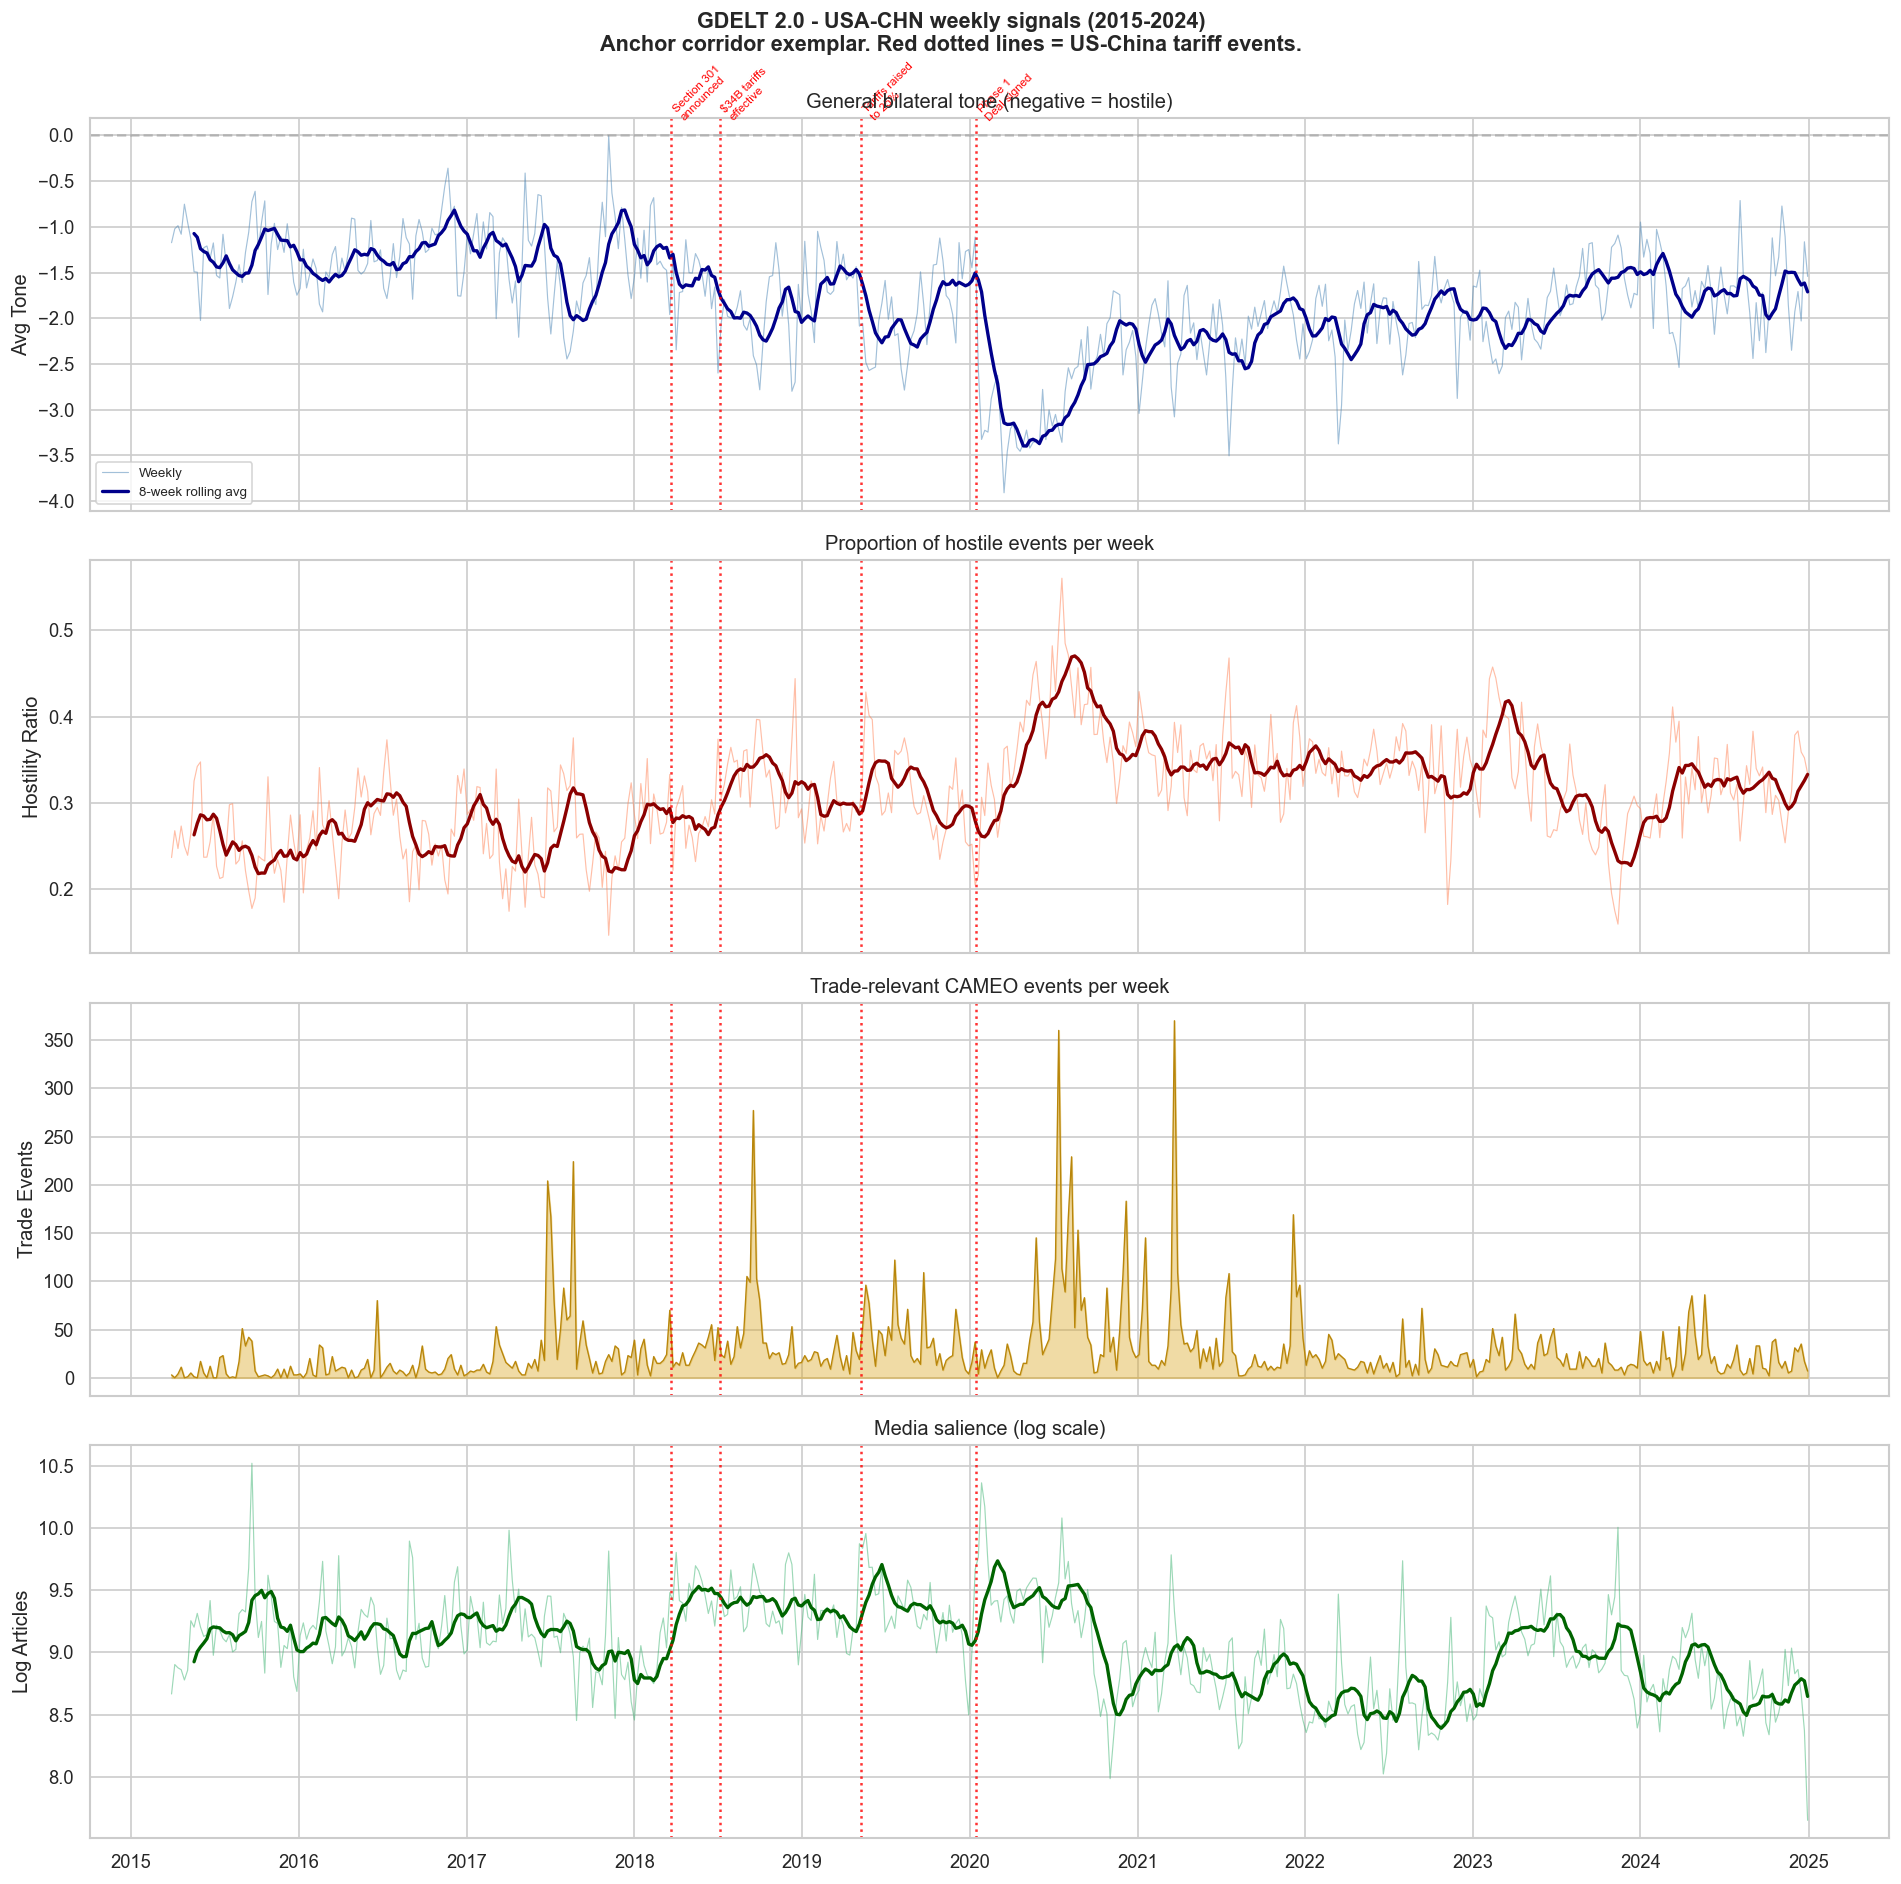

Saved: ../outputs/gdelt_usa_chn_timeseries.png

=== USA-CHN weekly summary ===
Weeks covered:                510
Mean tone (all weeks):        -1.804
Min tone (worst week):        -3.910
Mean hostility ratio:         0.311
Trade events total:           14,461
Weeks with trade events > 0:  492


In [69]:
# Anchor corridor detail — weekly time series, four feature panels
# Shows one corridor in depth as a worked exemplar. The next cell generalises
# to all 13 NVS corridors. Change ANCHOR_CORRIDOR to inspect a different pair.

import matplotlib.dates as mdates

ANCHOR_CORRIDOR = ('USA', 'CHN')   # densest signal, used as the worked example

a1, a2 = ANCHOR_CORRIDOR
label = f'{a1}-{a2}'

# Filter to anchor pair, both directions combined
anchor = gdelt_clean[
    ((gdelt_clean['actor1'] == a1) & (gdelt_clean['actor2'] == a2)) |
    ((gdelt_clean['actor1'] == a2) & (gdelt_clean['actor2'] == a1))
].copy()

anchor_weekly = anchor.groupby('week_start').agg(
    all_avg_tone=('all_avg_tone', 'mean'),
    all_avg_goldstein=('all_avg_goldstein', 'mean'),
    hostility_ratio=('hostility_ratio', 'mean'),
    trade_event_count=('trade_event_count', 'sum'),
    log_total_articles=('log_total_articles', 'mean'),
    tension_score=('tension_score', 'mean'),
    trade_avg_tone=('trade_avg_tone', 'mean')
).reset_index()

anchor_weekly['week_start'] = pd.to_datetime(anchor_weekly['week_start'])
anchor_weekly = anchor_weekly.sort_values('week_start')

# Tariff reference events — labels use newlines for plot annotation
TARIFF_EVENT_LABELS = {
    '2018-03-22': 'Section 301\nannounced',
    '2018-07-06': '$34B tariffs\neffective',
    '2019-05-10': 'Tariffs raised\nto 25%',
    '2020-01-15': 'Phase 1\nDeal signed',
}

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
fig.suptitle(
    f'GDELT 2.0 - {label} weekly signals (2015-2024)\n'
    'Anchor corridor exemplar. Red dotted lines = US-China tariff events.',
    fontsize=13, fontweight='bold'
)

# Panel 1: Avg tone
axes[0].plot(anchor_weekly['week_start'], anchor_weekly['all_avg_tone'],
             color='steelblue', linewidth=0.7, alpha=0.5, label='Weekly')
axes[0].plot(anchor_weekly['week_start'], anchor_weekly['all_avg_tone'].rolling(8).mean(),
             color='darkblue', linewidth=2, label='8-week rolling avg')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.4)
axes[0].set_ylabel('Avg Tone')
axes[0].set_title('General bilateral tone (negative = hostile)')
axes[0].legend(fontsize=8)

# Panel 2: Hostility ratio
axes[1].plot(anchor_weekly['week_start'], anchor_weekly['hostility_ratio'],
             color='coral', linewidth=0.7, alpha=0.5)
axes[1].plot(anchor_weekly['week_start'], anchor_weekly['hostility_ratio'].rolling(8).mean(),
             color='darkred', linewidth=2)
axes[1].set_ylabel('Hostility Ratio')
axes[1].set_title('Proportion of hostile events per week')

# Panel 3: Trade event count
axes[2].fill_between(anchor_weekly['week_start'], anchor_weekly['trade_event_count'],
                     alpha=0.4, color='goldenrod')
axes[2].plot(anchor_weekly['week_start'], anchor_weekly['trade_event_count'],
             color='darkgoldenrod', linewidth=0.8)
axes[2].set_ylabel('Trade Events')
axes[2].set_title('Trade-relevant CAMEO events per week')

# Panel 4: Log article volume
axes[3].plot(anchor_weekly['week_start'], anchor_weekly['log_total_articles'],
             color='mediumseagreen', linewidth=0.7, alpha=0.5)
axes[3].plot(anchor_weekly['week_start'], anchor_weekly['log_total_articles'].rolling(8).mean(),
             color='darkgreen', linewidth=2)
axes[3].set_ylabel('Log Articles')
axes[3].set_title('Media salience (log scale)')

for date_str, txt in TARIFF_EVENT_LABELS.items():
    event_date = pd.to_datetime(date_str)
    for ax in axes:
        ax.axvline(event_date, color='red', linestyle=':', alpha=0.8, linewidth=1.5)
    axes[0].text(event_date, axes[0].get_ylim()[1] * 0.85,
                 txt, fontsize=7, color='red', rotation=45, ha='left')

axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)

plt.tight_layout()
out_path = f'../outputs/gdelt_{a1.lower()}_{a2.lower()}_timeseries.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()

print(f'Saved: {out_path}')
print()
print(f'=== {label} weekly summary ===')
print(f'Weeks covered:                {len(anchor_weekly):,}')
print(f'Mean tone (all weeks):        {anchor_weekly["all_avg_tone"].mean():.3f}')
print(f'Min tone (worst week):        {anchor_weekly["all_avg_tone"].min():.3f}')
print(f'Mean hostility ratio:         {anchor_weekly["hostility_ratio"].mean():.3f}')
print(f'Trade events total:           {int(anchor_weekly["trade_event_count"].sum()):,}')
print(f'Weeks with trade events > 0:  {(anchor_weekly["trade_event_count"] > 0).sum():,}')

### What the anchor-corridor panels tell us

Each panel exposes a different aspect of the same underlying tension. Reading them together:

1. **Avg tone** drops sharply ahead of the first tariff event in March 2018, stays depressed across the 2018-2019 escalation window, and partially recovers after the Phase 1 deal. The rolling average makes the regime shift visible even when weekly noise is high. This is the strongest leading signal in the four panels.

2. **Hostility ratio** mirrors the tone signal but uses a different basis (proportion of hostile events, not their average score). When both panels move together, the regime shift is real, not an artifact of one or two heavy news weeks. When only one moves, treat the signal cautiously.

3. **Trade event count** is sparse by design (the trade-CAMEO filter is intentionally narrow). Spikes coincide with tariff escalation moments rather than preceding them. This is your highest-precision, lowest-recall feature.

4. **Media salience** (log article count) is sustained-high across the trade-war years with peaks at each escalation event. It captures attention even when the event itself is not trade-coded, making it useful as an intensity weight rather than a directional signal.

**Modelling implications.** Tone and hostility appear to lead tariff events by roughly 1-4 weeks for this corridor. Trade-CAMEO events are coincident-to-lagging. Article volume is not a directional signal on its own. The next cell repeats the tone view across all 13 NVS corridors so we can check whether this anchor pattern generalises or is unique to US-China.

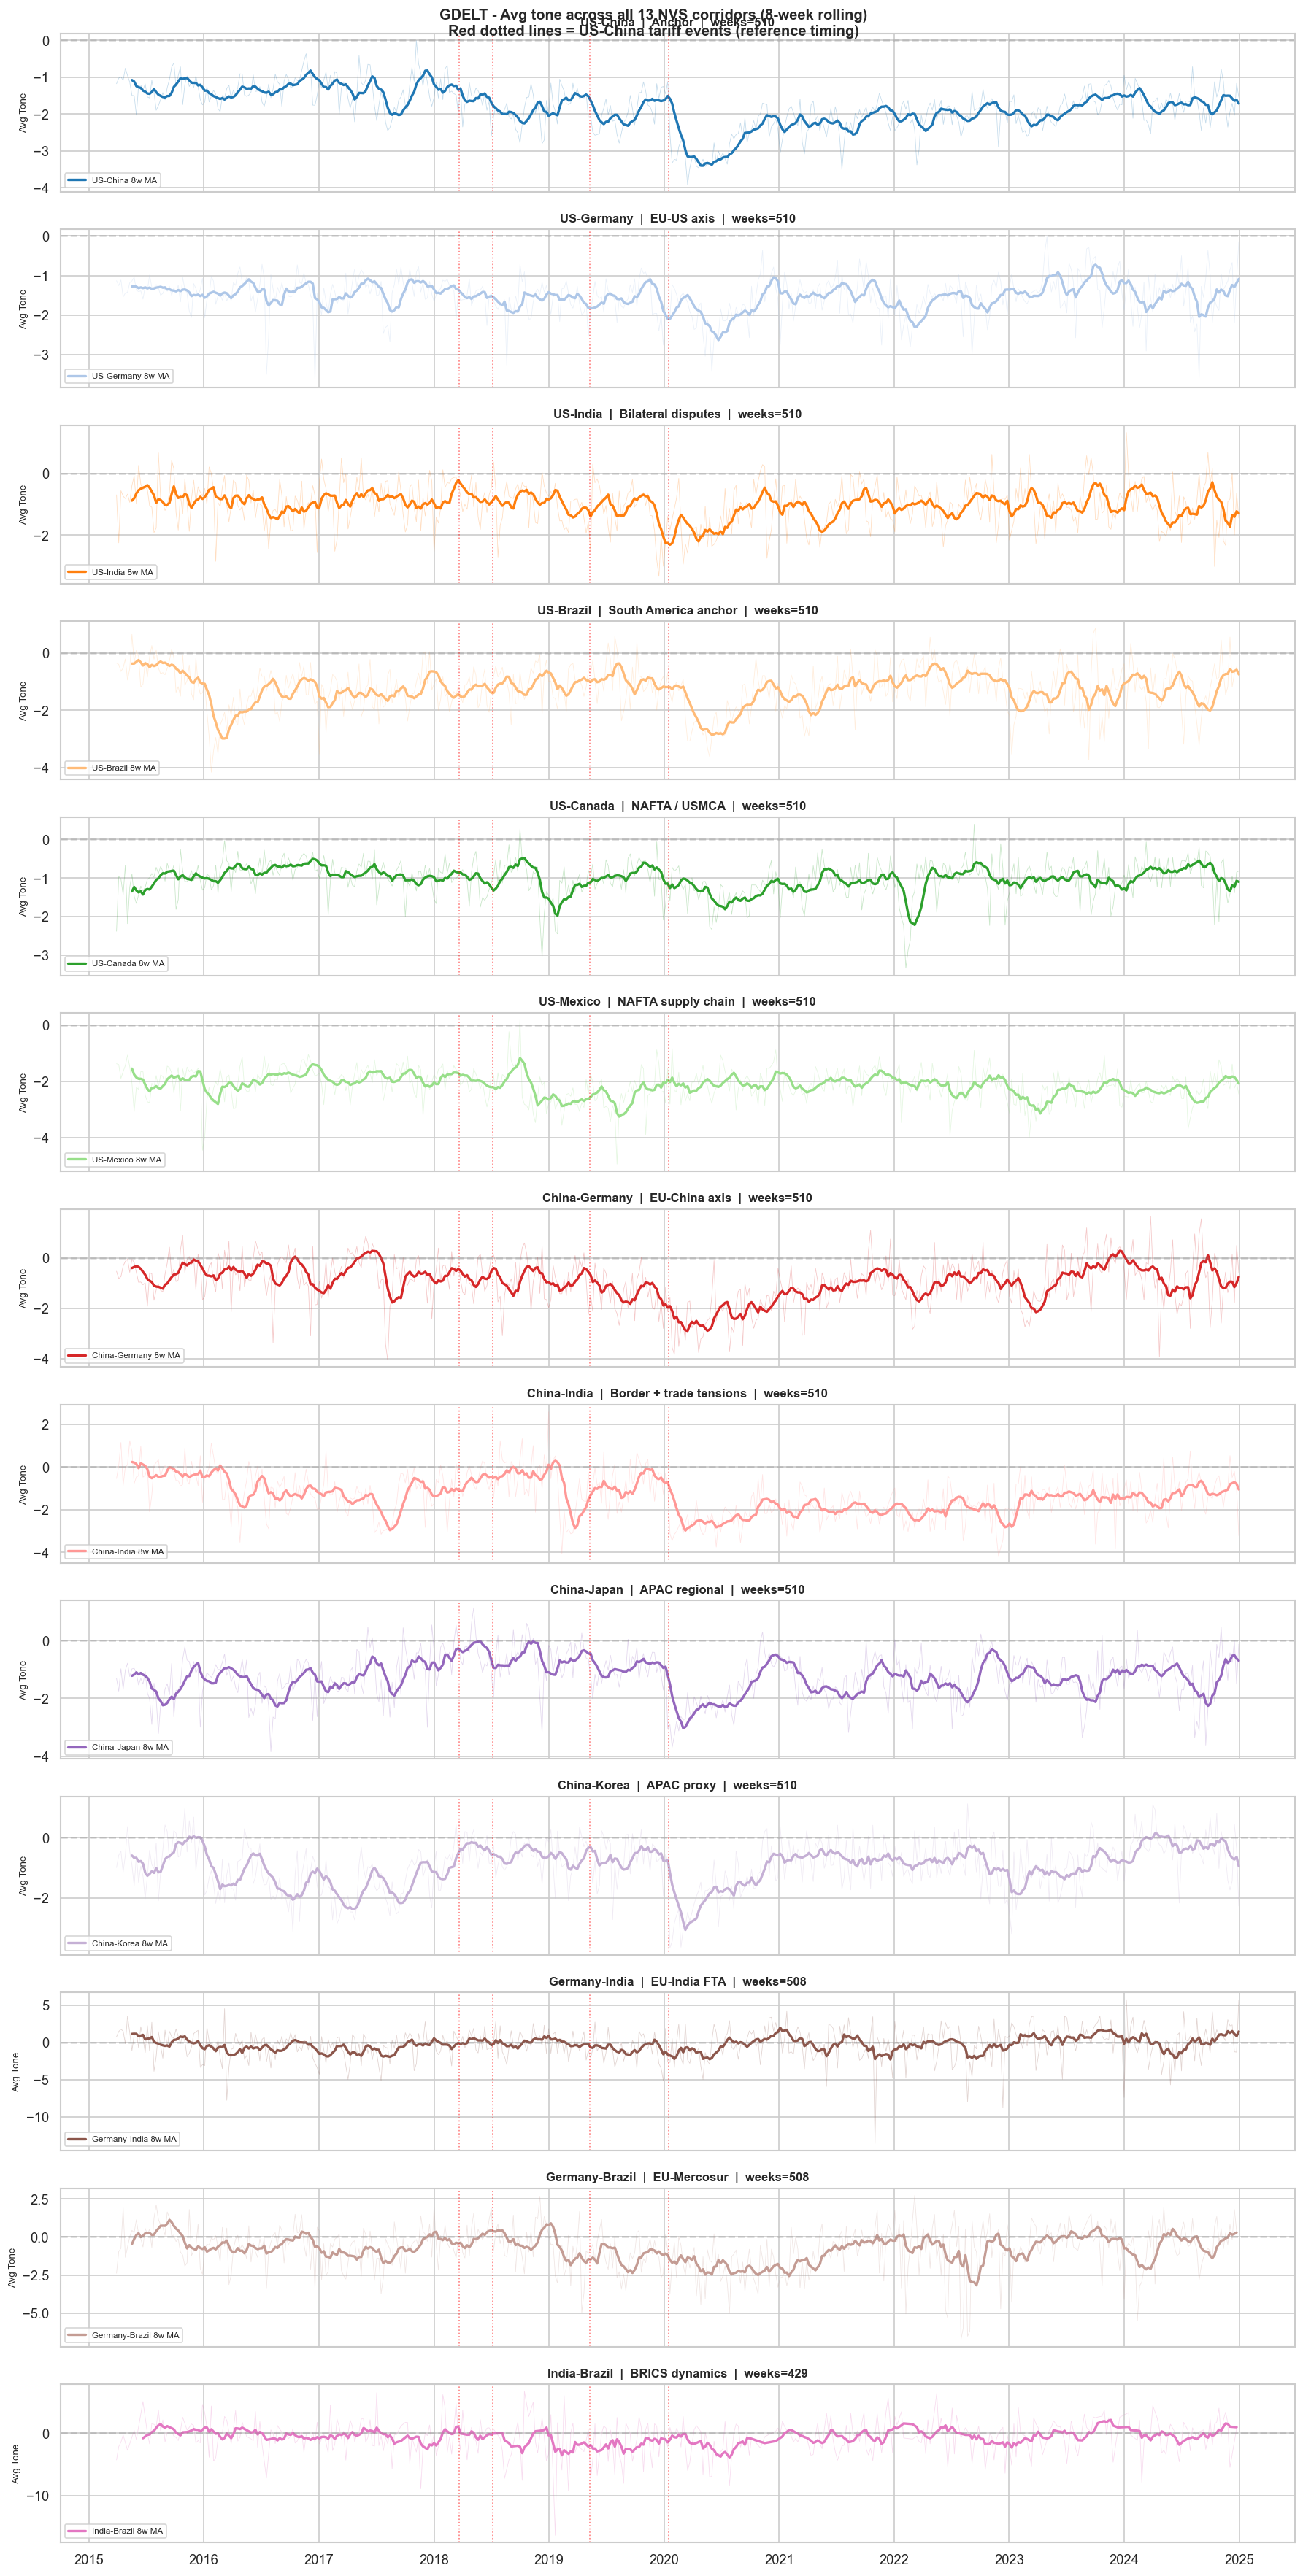

Saved: outputs/gdelt_all_corridors_tone_comparison.png

=== Tone summary by corridor ===


,corridor,reason,n_weeks,mean_tone,min_tone,tone_std
5,US-Mexico,NAFTA supply chain,510,-2.1290,-4.9490,0.5780
0,US-China,Anchor,510,-1.8040,-3.9100,0.6080
1,US-Germany,EU-US axis,510,-1.5130,-3.6510,0.4990
7,China-India,Border + trade tensions,510,-1.3500,-4.1660,1.0530
3,US-Brazil,South America anchor,510,-1.2620,-4.1580,0.8090
8,China-Japan,APAC regional,510,-1.2550,-3.8450,0.8120
4,US-Canada,NAFTA / USMCA,510,-1.0310,-3.3370,0.4750
2,US-India,Bilateral disputes,510,-1.0240,-3.3350,0.7110
6,China-Germany,EU-China axis,510,-0.9750,-4.0490,0.9620
9,China-Korea,APAC proxy,510,-0.9410,-3.6590,0.8410



=== Coverage check ===
Corridors with fewer than 300 weeks (sparse, may need bloc proxy):
  None - all 13 corridors have dense weekly coverage


In [70]:
# Multi-corridor tone comparison - all 13 NVS corridors
# Checks whether the anchor-corridor tone pattern generalises across the
# full set of corridors used by the model. CORRIDORS list matches the
# master 13-corridor set used in the ICEWS validation notebook.

CORRIDORS = [
    ('USA', 'CHN', 'US-China',       'Anchor'),
    ('USA', 'DEU', 'US-Germany',     'EU-US axis'),
    ('USA', 'IND', 'US-India',       'Bilateral disputes'),
    ('USA', 'BRA', 'US-Brazil',      'South America anchor'),
    ('USA', 'CAN', 'US-Canada',      'NAFTA / USMCA'),
    ('USA', 'MEX', 'US-Mexico',      'NAFTA supply chain'),
    ('CHN', 'DEU', 'China-Germany',  'EU-China axis'),
    ('CHN', 'IND', 'China-India',    'Border + trade tensions'),
    ('CHN', 'JPN', 'China-Japan',    'APAC regional'),
    ('CHN', 'KOR', 'China-Korea',    'APAC proxy'),
    ('DEU', 'IND', 'Germany-India',  'EU-India FTA'),
    ('DEU', 'BRA', 'Germany-Brazil', 'EU-Mercosur'),
    ('IND', 'BRA', 'India-Brazil',   'BRICS dynamics'),
]

fig, axes = plt.subplots(len(CORRIDORS), 1, figsize=(15, 30), sharex=True)
fig.suptitle(
    'GDELT - Avg tone across all 13 NVS corridors (8-week rolling)\n'
    'Red dotted lines = US-China tariff events (reference timing)',
    fontsize=12, fontweight='bold'
)

palette = plt.cm.tab20.colors
summary_rows = []

for i, (a1, a2, label, reason) in enumerate(CORRIDORS):
    pair_data = gdelt_clean[
        ((gdelt_clean['actor1'] == a1) & (gdelt_clean['actor2'] == a2)) |
        ((gdelt_clean['actor1'] == a2) & (gdelt_clean['actor2'] == a1))
    ].groupby('week_start').agg(
        all_avg_tone=('all_avg_tone', 'mean')
    ).reset_index()

    pair_data['week_start'] = pd.to_datetime(pair_data['week_start'])
    pair_data = pair_data.sort_values('week_start')

    ax = axes[i]
    color = palette[i % len(palette)]

    ax.plot(pair_data['week_start'], pair_data['all_avg_tone'],
            color=color, linewidth=0.5, alpha=0.25)
    ax.plot(pair_data['week_start'], pair_data['all_avg_tone'].rolling(8).mean(),
            color=color, linewidth=2, label=f'{label} 8w MA')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_ylabel('Avg Tone', fontsize=8)
    ax.set_title(
        f'{label}  |  {reason}  |  weeks={pair_data["week_start"].nunique()}',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=7, loc='lower left')

    for date_str in TARIFF_EVENT_LABELS.keys():
        ax.axvline(pd.to_datetime(date_str),
                   color='red', linestyle=':', alpha=0.5, linewidth=1.0)

    summary_rows.append({
        'corridor': label,
        'reason': reason,
        'n_weeks': pair_data['week_start'].nunique(),
        'mean_tone': round(pair_data['all_avg_tone'].mean(), 3),
        'min_tone': round(pair_data['all_avg_tone'].min(), 3),
        'tone_std': round(pair_data['all_avg_tone'].std(), 3),
    })

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/gdelt_all_corridors_tone_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/gdelt_all_corridors_tone_comparison.png')

print()
print('=== Tone summary by corridor ===')
summary_df = pd.DataFrame(summary_rows).sort_values('mean_tone')
display(summary_df)

print()
print('=== Coverage check ===')
print(f'Corridors with fewer than 300 weeks (sparse, may need bloc proxy):')
sparse = summary_df[summary_df['n_weeks'] < 300]
if len(sparse) == 0:
    print('  None - all 13 corridors have dense weekly coverage')
else:
    for _, r in sparse.iterrows():
        print(f'  {r["corridor"]:<18} {r["n_weeks"]} weeks  ({r["reason"]})')

### Reading the 13-corridor comparison

Three things to read off the panels and the printed summary table:

1. **Background tension** is captured by `mean_tone`. The corridor table is sorted from most-hostile to least-hostile mean tone. Corridors at the top (persistently negative mean tone) need different feature treatment than those near zero - the model should not treat a 0.5-point tone drop the same on a corridor that lives at -2 versus one that lives at 0.

2. **Coverage** is captured by `n_weeks`. Corridors with substantially fewer covered weeks than US-China are sparse in GDELT - typically because the bilateral relationship rarely generates news on its own. The coverage check below the table flags any corridor with under 300 weeks. These are candidates for bloc-level proxying (e.g. swap Germany-Brazil for EU-Brazil aggregate, or Germany-India for EU-India).

3. **Anchor pattern generalisation** is a visual check across the panels. Look for tone drops aligned with the 2018-2019 red lines. Corridors that show the drop are picking up the US-China spillover (expected for China's own pairs, possibly for EU pairs). Corridors that show no movement around those dates are not driven by the US-China shock and their tariff risk will be driven by different events entirely - which is exactly why we keep them in the model rather than relying on a US-China-only signal.

This view is GDELT-only. The cross-dataset reliability of these signals is established in the ICEWS validation notebook (`gdelt_vs_icews_master_validation.png`). A corridor that looks clean here but fails the ICEWS validation should be weighted down or proxied, regardless of how good its GDELT trajectory looks on its own.

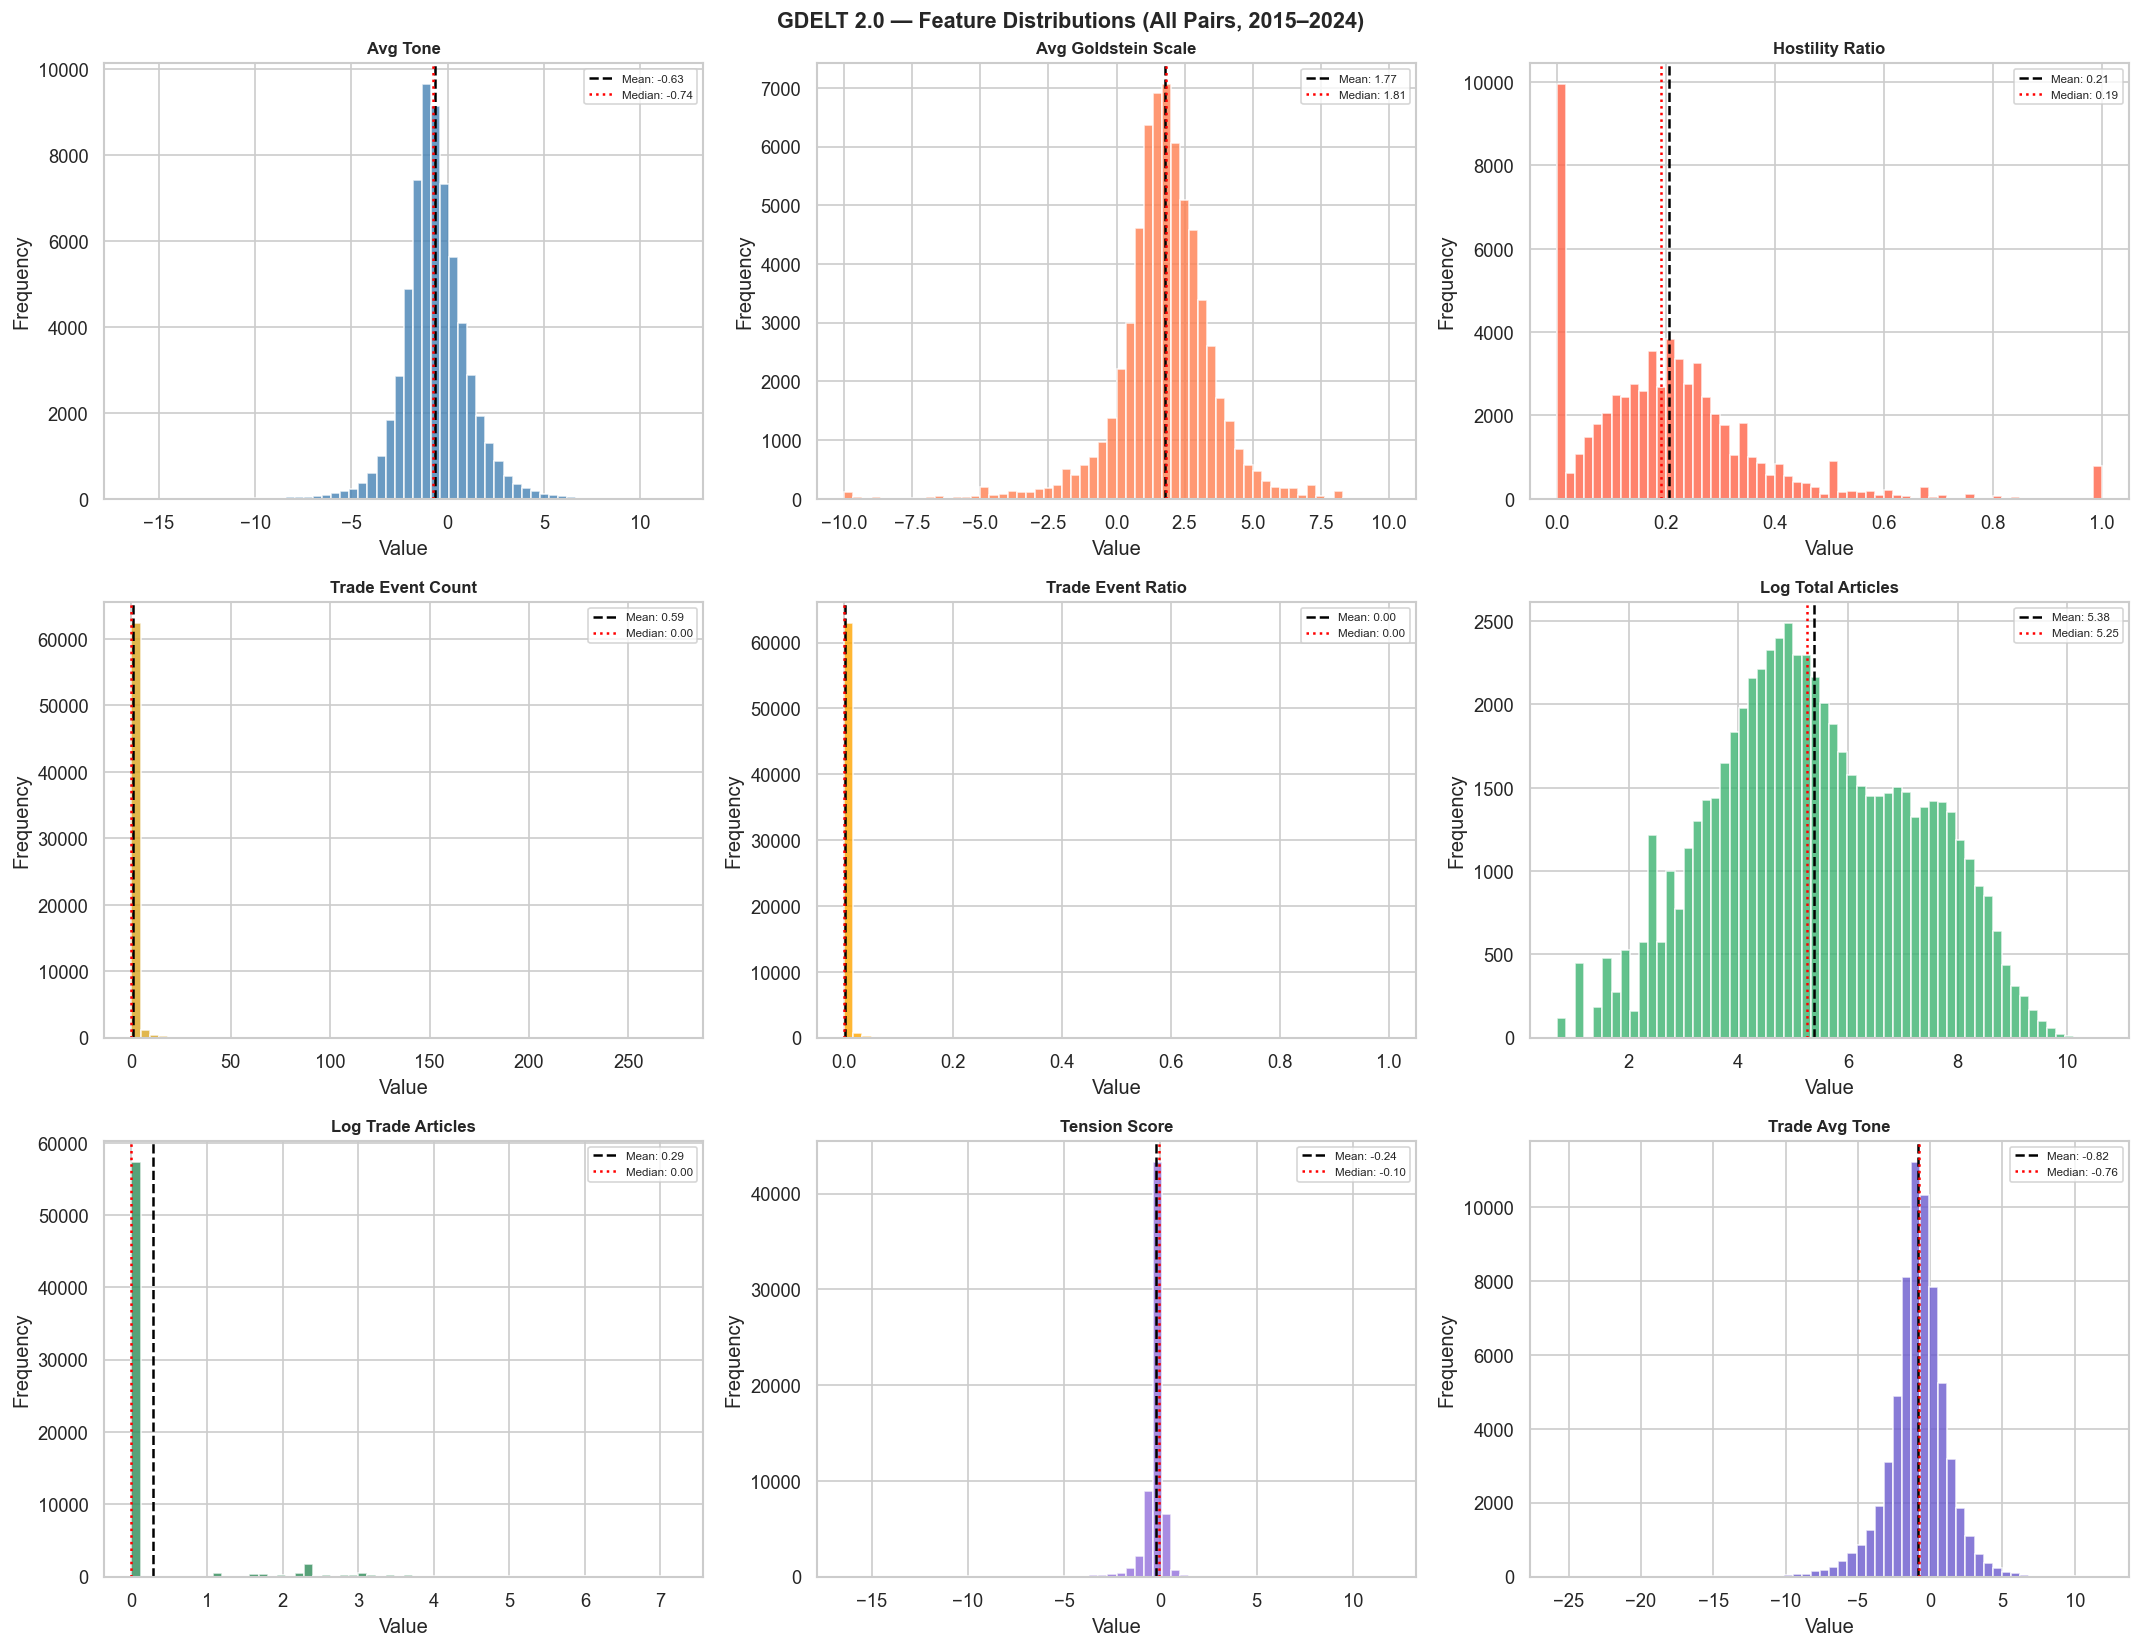

Saved: outputs/gdelt_feature_distributions.png

=== Skewness of Each Feature ===
(|skew| > 1 = significantly skewed = may need transformation)

Avg Tone                  skew =   0.023   Acceptable
Avg Goldstein Scale       skew =  -1.146   Transform recommended
Hostility Ratio           skew =   1.676   Transform recommended
Trade Event Count         skew =  27.565   Transform recommended
Trade Event Ratio         skew =  26.833   Transform recommended
Log Total Articles        skew =   0.026   Acceptable
Log Trade Articles        skew =   3.203   Transform recommended
Tension Score             skew =  -5.404   Transform recommended
Trade Avg Tone            skew =  -0.541   Acceptable


In [71]:
# Cell 14: Feature distribution analysis
# Understanding the shape of each feature
# before any modelling decisions

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'GDELT 2.0 — Feature Distributions (All Pairs, 2015–2024)',
    fontsize=13, fontweight='bold'
)

features_to_plot = [
    ('all_avg_tone',        'Avg Tone',              'steelblue'),
    ('all_avg_goldstein',   'Avg Goldstein Scale',   'coral'),
    ('hostility_ratio',     'Hostility Ratio',       'tomato'),
    ('trade_event_count',   'Trade Event Count',     'goldenrod'),
    ('trade_event_ratio',   'Trade Event Ratio',     'orange'),
    ('log_total_articles',  'Log Total Articles',    'mediumseagreen'),
    ('log_trade_articles',  'Log Trade Articles',    'seagreen'),
    ('tension_score',       'Tension Score',         'mediumpurple'),
    ('trade_avg_tone',      'Trade Avg Tone',        'slateblue'),
]

for idx, (col, label, color) in enumerate(features_to_plot):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row][col_idx]

    data = gdelt_clean[col].dropna()

    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(
        data.mean(), color='black',
        linestyle='--', linewidth=1.5,
        label=f'Mean: {data.mean():.2f}'
    )
    ax.axvline(
        data.median(), color='red',
        linestyle=':', linewidth=1.5,
        label=f'Median: {data.median():.2f}'
    )
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(
    '../outputs/gdelt_feature_distributions.png',
    dpi=120, bbox_inches='tight'
)
plt.show()

print('Saved: outputs/gdelt_feature_distributions.png')
print()

# Skewness check — important for model preparation
print('=== Skewness of Each Feature ===')
print('(|skew| > 1 = significantly skewed = may need transformation)')
print()
for col, label, _ in features_to_plot:
    skew_val = gdelt_clean[col].skew()
    flag = 'Transform recommended' if abs(skew_val) > 1 else 'Acceptable'
    print(f'{label:<25} skew = {skew_val:>7.3f}   {flag}')

### Reading the feature distributions

The skewness column at the bottom of the cell drives the next preprocessing step. Three groups of features emerge:

- **Roughly symmetric, model-ready.** `all_avg_tone`, `all_avg_goldstein`, `log_total_articles`, `log_trade_articles`, `trade_avg_tone`. These are usable as features without further transformation - the median and mean sit close to each other and the tails are not extreme.

- **Right-skewed, transformation recommended.** `trade_event_count`, `trade_event_ratio`, `tension_score`. A handful of escalation weeks pull the mean away from the median by an order of magnitude. The next preprocessing cell applies `log1p` to these so a model is not dominated by a few extreme weeks.

- **Structurally sparse, binary recommended.** `trade_event_count` is zero in roughly 90% of corridor-weeks. Even after log-transforming, the distribution is dominated by zeros. The next cell adds two binary flags - "any trade event this week" and "5+ trade events this week" - so a model has clean signals to work with rather than a near-degenerate distribution.

`hostility_ratio` is bounded `[0, 1]` so its raw distribution looks fine, but its meaning is corridor-specific (0.35 hostility on US-Canada is a crisis; 0.35 on US-China is a quiet week). That's why the later cell z-score-normalises it within each corridor pair rather than transforming it globally.

In [72]:
# save GDELT data as CSV to avoid BigQuery type issues

gdelt_clean['week_start'] = gdelt_clean['week_start'].astype(str)

gdelt_clean.to_csv('../outputs/gdelt_weekly_clean.csv', index=False)
print('Saved: outputs/gdelt_weekly_clean.csv')
print(f'Shape: {gdelt_clean.shape}')

Saved: outputs/gdelt_weekly_clean.csv
Shape: (64395, 19)


In [73]:
print(gdelt_clean.shape)
print(gdelt_clean.columns.tolist())

(64395, 19)
['week_start', 'actor1', 'actor2', 'all_event_count', 'all_avg_goldstein', 'all_min_goldstein', 'all_avg_tone', 'all_total_articles', 'all_total_mentions', 'trade_event_count', 'trade_avg_tone', 'trade_total_articles', 'cooperative_event_count', 'hostile_event_count', 'hostility_ratio', 'trade_event_ratio', 'log_total_articles', 'log_trade_articles', 'tension_score']


In [74]:
# Cell 15: Preprocessing — log transforms and binary flags

gdelt_pp = gdelt_clean.copy()

# Log transforms for right-skewed features
# log1p = log(x+1) handles zeros safely
gdelt_pp['log_trade_event_count'] = np.log1p(gdelt_pp['trade_event_count'])
gdelt_pp['log_tension_score_abs'] = np.log1p(np.abs(gdelt_pp['tension_score']))

# Binary flags for structurally sparse features
# Trade event ratio and count dominated by zeros — binary is more honest
gdelt_pp['trade_event_flag'] = (gdelt_pp['trade_event_count'] > 0).astype(int)
gdelt_pp['high_trade_activity'] = (gdelt_pp['trade_event_count'] >= 5).astype(int)

print('=== New columns added ===')
new_cols = ['log_trade_event_count','log_tension_score_abs',
            'trade_event_flag','high_trade_activity']
display(gdelt_pp[new_cols].describe())
print()
print(f'trade_event_flag = 1: {gdelt_pp["trade_event_flag"].sum():,} rows ({gdelt_pp["trade_event_flag"].mean()*100:.1f}%)')
print(f'high_trade_activity = 1: {gdelt_pp["high_trade_activity"].sum():,} rows ({gdelt_pp["high_trade_activity"].mean()*100:.1f}%)')

=== New columns added ===


,log_trade_event_count,log_tension_score_abs,trade_event_flag,high_trade_activity
count,64395.0000,64395.0000,64395.0000,64395.0000
mean,0.1556,0.2314,0.1084,0.0302
std,0.5109,0.2906,0.3109,0.1710
min,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0329,0.0000,0.0000
50%,0.0000,0.1446,0.0000,0.0000
75%,0.0000,0.3181,0.0000,0.0000
max,5.6168,2.8575,1.0000,1.0000



trade_event_flag = 1: 6,979 rows (10.8%)
high_trade_activity = 1: 1,942 rows (3.0%)


### Why these two transformations

**Log transforms on right-skewed features.** `trade_event_count` and `tension_score` both have extreme outlier weeks where values are orders of magnitude larger than the typical week. Left untreated, a single escalation week with hundreds of trade events would dominate the weights the model learns for these features - the model would effectively be learning from one unusual week rather than from the underlying pattern across the full corridor-week panel. Taking `log(x+1)` compresses those extreme values while preserving the relative ordering: a week with 10 events still looks more active than a week with 2, but the gap between 10 and 274 no longer distorts the model.

**Binary flags on structurally sparse features.** Roughly 90% of corridor-weeks contain zero trade events (printed above as `trade_event_flag = 1` rate). Keeping the raw count as a feature would give the model almost no variation to learn from across the majority of training data. Two flags are created instead:

- `trade_event_flag` - any week where at least one trade-relevant event occurred.
- `high_trade_activity` - any week with five or more trade events (the escalation signature).

Together these give the model a clean way to distinguish a quiet week from an active one, and an active week from an escalation peak, without requiring it to handle a distribution dominated by zeros and occasional extreme spikes.

In [75]:
# Cell 16: Normalise hostility ratio per country pair
# A hostility ratio of 0.35 means different things for
# US-China vs US-Canada — normalise within each pair

pair_stats = gdelt_pp.groupby(['actor1', 'actor2'])['hostility_ratio'].agg(
    pair_mean='mean',
    pair_std='std'
).reset_index()

gdelt_pp = gdelt_pp.merge(pair_stats, on=['actor1', 'actor2'], how='left')

# Z-score normalisation per pair
# (value - pair mean) / pair std
# Replaces raw ratio with how unusual this week is
# relative to that pair's own baseline
gdelt_pp['hostility_ratio_norm'] = (
    (gdelt_pp['hostility_ratio'] - gdelt_pp['pair_mean']) /
    gdelt_pp['pair_std'].replace(0, np.nan)
).fillna(0)

gdelt_pp = gdelt_pp.drop(columns=['pair_mean', 'pair_std'])

print('=== Hostility ratio normalisation check ===')
print()
print('Before normalisation:')
print(gdelt_pp['hostility_ratio'].describe().round(4))
print()
print('After normalisation:')
print(gdelt_pp['hostility_ratio_norm'].describe().round(4))
print()

# Spot check: US-China should show higher normalised values in 2018
us_china_check = gdelt_pp[
    ((gdelt_pp['actor1'] == 'USA') & (gdelt_pp['actor2'] == 'CHN')) |
    ((gdelt_pp['actor1'] == 'CHN') & (gdelt_pp['actor2'] == 'USA'))
].copy()
us_china_check['week_start'] = pd.to_datetime(us_china_check['week_start'])
peak = us_china_check.nlargest(3, 'hostility_ratio_norm')[
    ['week_start', 'hostility_ratio', 'hostility_ratio_norm']
]
print('Top 3 most abnormally hostile US-China weeks:')
display(peak)

=== Hostility ratio normalisation check ===

Before normalisation:
count   64395.0000
mean        0.2059
std         0.1711
min         0.0000
25%         0.0909
50%         0.1914
75%         0.2770
max         1.0000
Name: hostility_ratio, dtype: Float64

After normalisation:
count   64395.0000
mean       -0.0000
std         0.9990
min        -3.2481
25%        -0.7013
50%        -0.2087
75%         0.5419
max         8.0209
Name: hostility_ratio_norm, dtype: Float64

Top 3 most abnormally hostile US-China weeks:


,week_start,hostility_ratio,hostility_ratio_norm
35362,2020-07-20,0.5796,4.3949
35442,2020-07-20,0.5410,3.3715
35323,2020-07-13,0.5278,3.1720


In [76]:
# Cell 17: Forward-fill remaining missing values
# Then verify preprocessing is complete

gdelt_pp['week_start'] = pd.to_datetime(gdelt_pp['week_start'])
gdelt_pp = gdelt_pp.sort_values(['actor1', 'actor2', 'week_start'])

# Forward-fill within each country pair
# Only affects features where missingness is structural
fill_cols = ['all_avg_tone', 'trade_avg_tone', 'all_avg_goldstein']

for col in fill_cols:
    gdelt_pp[col] = gdelt_pp.groupby(
        ['actor1', 'actor2']
    )[col].ffill()

# Final null check
print('=== Final missing value check ===')
nulls = gdelt_pp.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) == 0:
    print('No missing values remaining.')
else:
    display(nulls)

print()
print(f'Final shape: {gdelt_pp.shape}')
print(f'Total features: {gdelt_pp.shape[1] - 3} (excluding week_start, actor1, actor2)')
print()
print('=== Final column list ===')
for col in gdelt_pp.columns:
    print(f'  {col}')

=== Final missing value check ===
No missing values remaining.

Final shape: (64395, 24)
Total features: 21 (excluding week_start, actor1, actor2)

=== Final column list ===
  week_start
  actor1
  actor2
  all_event_count
  all_avg_goldstein
  all_min_goldstein
  all_avg_tone
  all_total_articles
  all_total_mentions
  trade_event_count
  trade_avg_tone
  trade_total_articles
  cooperative_event_count
  hostile_event_count
  hostility_ratio
  trade_event_ratio
  log_total_articles
  log_trade_articles
  tension_score
  log_trade_event_count
  log_tension_score_abs
  trade_event_flag
  high_trade_activity
  hostility_ratio_norm


In [77]:
# Cell 18: Save preprocessed GDELT data

gdelt_pp.to_csv('../outputs/gdelt_preprocessed.csv', index=False)

print('Saved: outputs/gdelt_preprocessed.csv')
print(f'Shape: {gdelt_pp.shape}')
print(f'Date range: {gdelt_pp["week_start"].min()} to {gdelt_pp["week_start"].max()}')
print()
print('=== Preprocessing summary ===')
print('Original features:     19 columns')
print('After preprocessing:   24 columns (+5 engineered)')
print()
print('Added:')
print('  log_trade_event_count  — log transform of raw trade count')
print('  log_tension_score_abs  — log transform of tension magnitude')
print('  trade_event_flag       — binary: any trade event this week')
print('  high_trade_activity    — binary: 5+ trade events this week')
print('  hostility_ratio_norm   — z-score normalised per country pair')
print()
print('Ready for: ICEWS validation → feature engineering')

Saved: outputs/gdelt_preprocessed.csv
Shape: (64395, 24)
Date range: 2015-03-30 00:00:00 to 2024-12-30 00:00:00

=== Preprocessing summary ===
Original features:     19 columns
After preprocessing:   24 columns (+5 engineered)

Added:
  log_trade_event_count  — log transform of raw trade count
  log_tension_score_abs  — log transform of tension magnitude
  trade_event_flag       — binary: any trade event this week
  high_trade_activity    — binary: 5+ trade events this week
  hostility_ratio_norm   — z-score normalised per country pair

Ready for: ICEWS validation → feature engineering
